In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import matplotlib.colors as colors
# import holoviews as hv
import gzip
from matplotlib.patches import Rectangle

import matplotlib as mpl
from cycler import cycler
# hv.extension('bokeh')
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.signal import peak_widths
from scipy.signal import savgol_filter
from numpy.fft import rfft, rfftfreq

In [2]:
import os

In [3]:
def load1d(i):
    return np.loadtxt(os.path.join('..', '20231026_HMIA13_6 QD', 'data', str(i), 'data.tsv'))

def load1dHMIA13_3(i):
    return np.loadtxt(os.path.join('..', '20221123 HMIA 13-3 Kondo', 'data', str(i), 'data.tsv'))

def load2d(i, num):
    tmp = np.loadtxt(os.path.join('..', '20231026_HMIA13_6 QD', 'data', str(i), 'data.tsv'))
    numrows = np.floor(tmp.shape[0] / num)
    data_dict = {}
    for j in range(tmp.shape[1]):
        data_dict[str(j)] = tmp[:num*int(numrows), j].reshape((int(numrows), num)).transpose()
    return data_dict

In [4]:
q1 = 100.075
q2 = 100.103
q3 = 100.087
q4 = 100.082

s1 = 100.104
s2 = 99.977
s3 = 100.183

In [5]:
import glob
import os

# search_dir = 'G:\\Shared drives\\GGG GDrive\\Pink Fridge Data\\20231026_HMIA13_6 QD\\data\\'
#lia_dir = 'G:\\Shared drives\\GGG GDrive\\Pink Fridge Data\\20231026_HMIA13_6 QD\\data\\lia\\'
lia_dir = os.path.join('..', '20231026_HMIA13_6 QD', 'data', 'lia')
# remove anything from the list that is not a file (directories, symlinks)
# thanks to J.F. Sebastion for pointing out that the requirement was a list
# of files (presumably not including directories)
#files = list(filter(os.path.isfile, glob.glob(search_dir + "*")))
#files.sort(key=lambda x: os.path.getmtime(x))

def sortedfilelist(lia_dir):
    os.chdir(lia_dir)
    lia_dir_abs = os.getcwd()
    files =os.listdir(lia_dir_abs)
    files.sort(key=lambda x: os.path.getmtime(x))
    os.chdir(os.path.join('..', '..', '..', 'figureM2'))
    return files

In [6]:
os.getcwd()

'/Users/karnamorey/Documents/InAsHybridDots/figureM3'

In [7]:
def noisepsd(dat, fs, rms=True):
    dat = dat - np.mean(dat)
    datfft = rfft(dat)
    fftfreq = rfftfreq(len(dat), 1/fs)
    if rms:
        scale = 2
    else:
        scale = np.sqrt(2)

    inoise_psd = 1*((len(dat)/fs)*(1*(1/(25813/3))*((scale/len(dat)*np.abs(datfft)))/1)**2)# A^2/Hz

    return fftfreq, inoise_psd

['231102_noiseinCB_500pAlia_Vgm520.00mV.txt.gz', '231102_sourcing10mV_lia.txt.gz', '231102_noiseinCB_500pAlia_Vgm499.99mVch2.txt.gz', '231102_noiseinCB_500pAlia_Vgm499.99mVch1.txt.gz', '231102_noiseinCB_5nAlia_Vgm499.99mVch2.txt.gz', '231102_noiseinCB_5nAlia_Vgm499.99mVch1.txt.gz', '231102_noiseinCB_5nAlia_Vgm516.64mVch2.txt.gz', '231102_noiseinCB_5nAlia_Vgm516.64mVch1.txt.gz', '231102_noiseinCB_5nAlia_Vgm510.81mVch1.txt.gz', '231102_noiseinCB_5nAlia_Vgm510.81mVch2.txt.gz', '231102_noisefloor_singlechamp1.txt.gz', '231102_noisefloor_singlechamp2.txt.gz', '231102_noisefloor_1xquadampchamp1.txt.gz', '231102_noisefloor_1xquadampchamp2.txt.gz', '231102_noisefloor_2xquadampchamp2.txt.gz', '231102_noisefloor_2xquadampchamp1.txt.gz', '231102_noiseinCB_5nAlia_Vgm520.0mVch1.txt.gz', '231102_noiseinCB_5nAlia_Vgm520.0mVch2.txt.gz', '231102_noiseinCB_10nAlia_Vgm515.8mVch1.txt.gz', '231102_noiseinCB_10nAlia_Vgm515.8mVch2.txt.gz', '231102_noiseinCB_500pAlia860_Vgm510.0mVch2.txt.gz', '231102_noiseinC

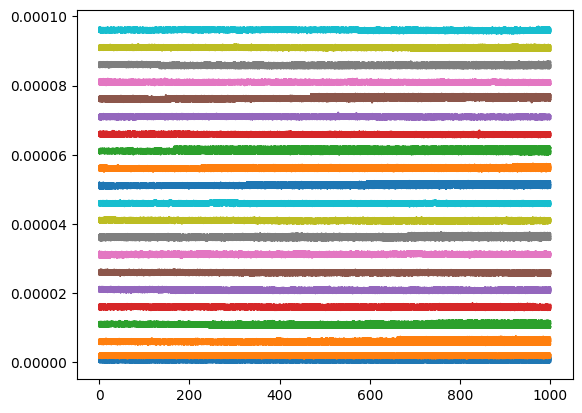

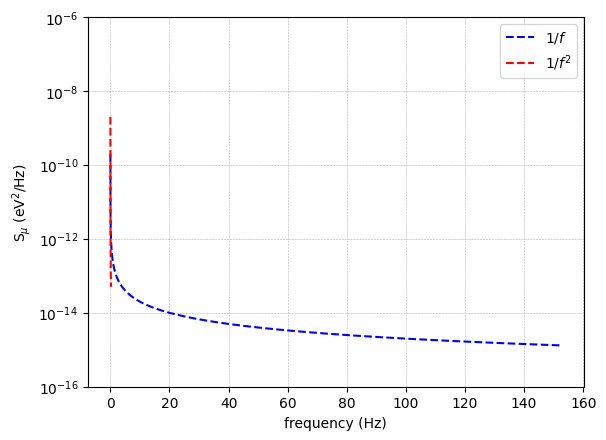

In [8]:
fig, ax = plt.subplots()
fig2, ax2 = plt.subplots()
# ax3 = ax2.twiny()

dat10 = np.loadtxt(os.path.join('..', '20231026_HMIA13_6 QD', 'data', 'lia', '231102_SR860noisefloor_fs300_tc3ms_FIRfilter.txt.gz'))
firstfile =  '231107_1000s_syncOFF_liaf88Hz_noiseonleftCBF_rplunger_fs300_tc3ms_FIRfilter_5nAlia860only_Vgm502.8mVR_iter0.txt.gz'
numfiles = 20
filelist = sortedfilelist(lia_dir)
print(filelist)
startindex = filelist.index(firstfile)
fs = 305.18
alpha = 0.18/6
slope = 0.0017
time = np.arange(0, 1000, 1/fs)
chargenoise_psd = np.zeros((numfiles, int((1/1.00001638e-03)*fs/2) + 1))
counter = 0
chargenoisesum = np.zeros((int((1/1.00001638e-03)*fs/2) + 1,))

lchargenoise_psdarr = []
rchargenoise_psdarr = []
for peaknum in range(numfiles):


    if peaknum%1==0:
        dat = np.loadtxt(os.path.join(lia_dir, filelist[startindex+peaknum]))
        sigma = np.std(dat)

        with gzip.open(os.path.join(lia_dir, filelist[startindex+peaknum]),'r') as f:
            firstline = f.readline()
            header = str(firstline).split(',')
            slope = float(header[3])
            print(slope)
        f.close()

        if 1e9*sigma < 300:
            flag=1
            counter+=1
        else:
            flag=0

        ax.plot(time[:len(dat)], dat+peaknum*1*5e-6, label='peaknum = %1.f, $\sigma = $ %2.f nV' %(peaknum, 1e9*sigma))
        print(1e9*sigma)
        print(flag)
        print('--')
        f, noise = noisepsd(dat, fs, rms=True)

        chargenoise_psd[peaknum, :] = noise*((25813/3)**2)*(alpha**2)/(slope**2)
        chargenoisesum = chargenoisesum + flag*chargenoise_psd[peaknum, :]
        if flag:
            lchargenoise_psdarr.append(noise*((25813/3)**2)*(alpha**2)/(slope**2))
        # ax2.semilogy(f, chargenoise_psd[peaknum, :])


avgchargenoise_left = chargenoisesum/counter
# ax2.semilogy(f, chargenoisesum/counter, ls='--', color='b')



firstfile = '231107_1000s_syncOFF_liaf88Hz_noiseonrightCBF_rplunger_fs300_tc3ms_FIRfilter_5nAlia860only_Vgm499.6mVR_iter0.txt.gz'
numfiles = 20
filelist = sortedfilelist(lia_dir)
startindex = filelist.index(firstfile)
fs = 305.18
alpha = 0.18/6
slope = 0.0017
time = np.arange(0, 1000, 1/fs)
chargenoise_psd = np.zeros((numfiles, int((1/1.00001638e-03)*fs/2) + 1))
counter = 0
chargenoisesum = np.zeros((int((1/1.00001638e-03)*fs/2) + 1,))
for peaknum in range(numfiles):


    if peaknum%1==0:
        dat = np.loadtxt(os.path.join(lia_dir, filelist[startindex+peaknum]))
        sigma = np.std(dat)

        with gzip.open(os.path.join(lia_dir, filelist[startindex+peaknum]),'r') as f:
            firstline = f.readline()
            header = str(firstline).split(',')
            slope = float(header[3])
            print(slope)
        f.close()

        if 1e9*sigma < 300:
            flag=1
            counter+=1
        else:
            flag=0

        ax.plot(time[:len(dat)], dat+peaknum*1*5e-6, label='peaknum = %1.f, $\sigma = $ %2.f nV' %(peaknum, 1e9*sigma))
        print(1e9*sigma)
        print(flag)
        print('--')
        f, noise = noisepsd(dat, fs, rms=True)

        chargenoise_psd[peaknum, :] = noise*((25813/3)**2)*(alpha**2)/(slope**2)
        chargenoisesum = chargenoisesum + flag*chargenoise_psd[peaknum, :]
        if flag:
            rchargenoise_psdarr.append(noise*((25813/3)**2)*(alpha**2)/(slope**2))
        # ax2.semilogy(f, chargenoise_psd[peaknum, :])


avgchargenoise_right = chargenoisesum/counter
# ax2.semilogy(f, chargenoisesum/counter, ls='--', color='r')


# firstfile = '231107_1000s_syncOFF_liaf88Hz_noiseonleftCBF_rplunger_fs300_tc3ms_FIRfilter_5nAlia860_Vgm500.6mVR_iter0.txt.gz'
# numfiles = 10
# filelist = sortedfilelist(lia_dir)
# startindex = filelist.index(firstfile)
# fs = 305.18
# alpha = 0.18/6
# slope = 1e-3
# time = np.arange(0, 1000, 1/fs)
# chargenoise_psd = np.zeros((numfiles, int((1/1.00001638e-03)*fs/2) + 1))
# counter = 0
# chargenoisesum = np.zeros((int((1/1.00001638e-03)*fs/2) + 1,))
# for peaknum in range(numfiles):


#     if peaknum%1==0:
#         dat = np.loadtxt(filelist[startindex+peaknum])
#         sigma = np.std(dat)

#         if 1e9*sigma < 1000:
#             flag=1
#             counter+=1
#         else:
#             flag=0

#         ax.plot(time[:len(dat)], dat+peaknum*1*5e-6, label='peaknum = %1.f, $\sigma = $ %2.f nV' %(peaknum, 1e9*sigma))
#         print(1e9*sigma)
#         print(flag)
#         print('--')
#         f, noise = noisepsd(dat, fs, rms=True)

#         chargenoise_psd[peaknum, :] = noise*((25813/3)**2)*(alpha**2)/(slope**2)
#         chargenoisesum = chargenoisesum + flag*chargenoise_psd[peaknum, :]
        # ax2.semilogy(f, chargenoise_psd[peaknum, :])



# ax2.semilogy(f, chargenoisesum/counter, ls='--', color='k')
firstfile = '231108_1000s_syncOFF_liaf88Hz_noiseonCBV_rplunger_fs300_tc3ms_FIRfilter_5nAlia860only_Vgm500.0mVR_iter0.txt.gz'
numfiles = 1
filelist = sortedfilelist(lia_dir)
startindex = filelist.index(firstfile)
fs = 305.18
alpha = 0.18/6
slope = 0.0017
time = np.arange(0, 1000, 1/fs)
chargenoise_psd = np.zeros((numfiles, int((1/1.00001638e-03)*fs/2) + 1))
counter = 0
chargenoisesum = np.zeros((int((1/1.00001638e-03)*fs/2) + 1,))
for peaknum in range(numfiles):


    if peaknum%1==0:
        dat = np.loadtxt(os.path.join(lia_dir, filelist[startindex+peaknum]))
        sigma = np.std(dat)

        if 1e9*sigma < 300:
            flag=1
            counter+=1
        else:
            flag=0

        ax.plot(time[:len(dat)], dat+peaknum*1*5e-6, label='peaknum = %1.f, $\sigma = $ %2.f nV' %(peaknum, 1e9*sigma))
        print(1e9*sigma)
        print(flag)
        print('--')
        f, noise = noisepsd(dat, fs, rms=True)

        chargenoise_psd[peaknum, :] = noise*((25813/3)**2)*(alpha**2)/(slope**2)
        chargenoisesum = chargenoisesum + flag*chargenoise_psd[peaknum, :]
        # ax2.semilogy(f, chargenoise_psd[peaknum, :])


cbv = chargenoisesum/counter


firstfile = '231108_1000s_syncOFF_liaf88Hz_noiseonCBP_rplunger_fs300_tc3ms_FIRfilter_5nAlia860only_Vgm504.3mVR_iter0.txt.gz'
numfiles = 1
filelist = sortedfilelist(lia_dir)
startindex = filelist.index(firstfile)
fs = 305.18
alpha = 0.18/6
slope = 0.0017
time = np.arange(0, 1000, 1/fs)
chargenoise_psd = np.zeros((numfiles, int((1/1.00001638e-03)*fs/2) + 1))
counter = 0
chargenoisesum = np.zeros((int((1/1.00001638e-03)*fs/2) + 1,))
for peaknum in range(numfiles):


    if peaknum%1==0:
        dat = np.loadtxt(os.path.join(lia_dir, filelist[startindex+peaknum]))
        sigma = np.std(dat)

        if 1e9*sigma < 300:
            flag=1
            counter+=1
        else:
            flag=0

        ax.plot(time[:len(dat)], dat+peaknum*1*5e-6, label='peaknum = %1.f, $\sigma = $ %2.f nV' %(peaknum, 1e9*sigma))
        print(1e9*sigma)
        print(flag)
        print('--')
        f, noise = noisepsd(dat, fs, rms=True)

        chargenoise_psd[peaknum, :] = noise*((25813/3)**2)*(alpha**2)/(slope**2)
        chargenoisesum = chargenoisesum + flag*chargenoise_psd[peaknum, :]
        # ax2.semilogy(f, chargenoise_psd[peaknum, :])


cbp = chargenoisesum/counter

ax2.loglog(f[1:], 2e-13/f[1:]**1, ls='--', label='$1/f$', color='b')
ax2.loglog(f[1:200], 2e-15/f[1:200]**2, ls='--', label='$1/f^2$', color='r')
fnoisefloor300, noisefloor300 =  noisepsd(dat10, fs, rms=True)
chargenoisefloor300 = noisefloor300*((25813/3)**2)*(alpha**2)/(slope**2)

ax2.set_ylim(1e-16, 1e-6)
ax2.set_xscale('linear')
# ax2.set_xlim(2, 5)
ax2.set_xlabel('frequency (Hz)')
ax2.set_ylabel('S$_{\mu}$ (eV$^2$/Hz)')
ax2.grid(ls='--', lw=0.4, which='both')
ax2.legend()

Text(0, 0.5, 'charge noise (eV$^2$/Hz)')

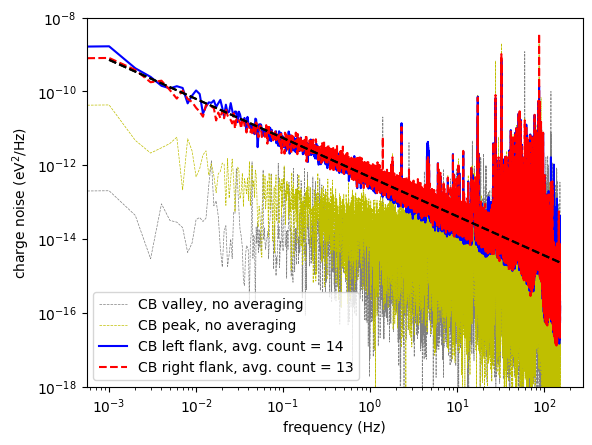

In [9]:
fig2, ax2 = plt.subplots()
ax2.loglog(f, cbv, color='gray', ls='--', lw=0.5, label='CB valley, no averaging')
ax2.loglog(f, cbp, color='y', ls='--', lw=0.5, label='CB peak, no averaging')
ax2.loglog(f, avgchargenoise_left, 'b', label='CB left flank, avg. count = 14')
ax2.loglog(f, avgchargenoise_right, 'r--', label='CB right flank, avg. count = 13')
a1,b1 = np.polyfit(np.log(f[1:1001]), np.log(avgchargenoise_left[1:1001]), 1)
a2,b2 = np.polyfit(np.log(f[1:1001]), np.log(avgchargenoise_left[1:1001]), 1)

ax2.plot(f[1:], np.exp(b1)*f[1:]**a1, ls='--', color='k')
ax2.plot(f[1:], np.exp(b2)*f[1:]**a2, ls='--', color='k')
ax2.legend(loc = 'lower left')
# ax2.set_xscale('linear')
# # ax2.set_xscale('linear')
# ax2.set_xlim(5,10)
ax2.set_ylim(1e-18, 1e-8)
ax2.set_xlabel('frequency (Hz)')
ax2.set_ylabel('charge noise (eV$^2$/Hz)')

14
13
[4.41645328e-01 5.41791029e-01 1.22152782e-01 1.49903230e+00
 4.63144701e-01 5.12461465e-01 1.09775541e+00 3.71863366e-02
 2.37747606e-01 3.24260823e-01 5.69708866e-01 1.10946153e-03
 1.30117660e-01 3.12968946e-01]
0.4493630506980574 0.1101526226588353


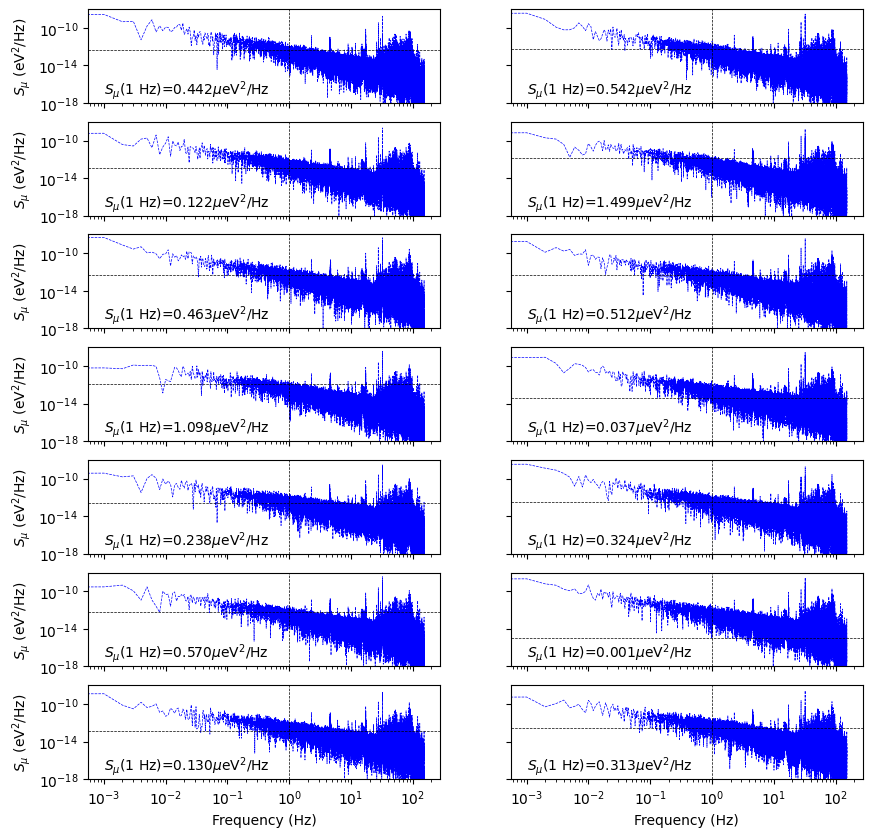

In [10]:
fig2, axes = plt.subplots(nrows = 7, ncols = 2, sharex = True, sharey = True, figsize = (10, 10))
print(len(lchargenoise_psdarr))
print(len(rchargenoise_psdarr))
oneindex = np.argmin(np.abs(f - 1))
larr_onehz = []
for k in range(len(lchargenoise_psdarr)):
    onehz = lchargenoise_psdarr[k][oneindex]
    larr_onehz.append(onehz)
    axes[k//2, k%2].loglog(f, lchargenoise_psdarr[k], color='blue', ls='--', lw=0.5, label='left')
    #axes.loglog(f, rchargenoise_psdarr[0], color='y', ls='--', lw=0.5, label='CB peak, no averaging')
    axes[k//2, k%2].set_ylim(1e-18, 1e-8)
    axes[k//2, 0].set_ylabel(r'$S_\mu$ (eV$^2$/Hz)')
    axes[k//2, k%2].axvline(1, color = 'black', lw = 0.5, ls = '--')
    axes[k//2, k%2].axhline(onehz, color = 'black', lw = 0.5, ls = '--')
    axes[k//2, k%2].text(1e-3, 1e-17, rf'$S_\mu$(1 Hz)={onehz*1e12:.3f}$\mu$eV$^2$/Hz')

axes[6, 0].set_xlabel('Frequency (Hz)')
axes[6, 1].set_xlabel('Frequency (Hz)')
lonehznoise = np.array(larr_onehz)*1e12 ## units of ueV^2/Hz
print(lonehznoise)
print(np.mean(lonehznoise), np.std(lonehznoise)/np.sqrt(13))